In [ ]:
import pandas as pd

df = pd.read_csv("C:\\Users\\tempu\\Downloads\\research\\labs\\gratton\\Arousal-Project\\splitting_sample\\self_report\\iNET_sleep_scores_and_times.csv")
df.head()

,sub,ses,task,run,filename,number_of_TRs,abnormal_TR,error_run,note,sleepiness__1_7_scale_,...,confidence,alignment,tmask_filepath,tmask_filename,num_tps_retained,percent_tps_retained,fFD_filepath,fFD_filename,mean_fFD,max_fFD
0,sub-INET001,ses-1,task-rest,run-01,sub-INET001_ses-1_task-rest_run-01_bold.nii.gz,270,0,NaN,NaN,1.0,...,NaN,include,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-01_desc-tmask_...,263,97.407407,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-01_desc-fFD.txt,0.026217,0.166371
1,sub-INET001,ses-1,task-rest,run-02,sub-INET001_ses-1_task-rest_run-02_bold.nii.gz,270,0,NaN,NaN,1.0,...,NaN,include,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-02_desc-tmask_...,265,98.148148,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-02_desc-fFD.txt,0.024525,0.084208
2,sub-INET001,ses-1,task-rest,run-03,sub-INET001_ses-1_task-rest_run-03_bold.nii.gz,270,0,NaN,NaN,1.0,...,NaN,include,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-03_desc-tmask_...,265,98.148148,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-03_desc-fFD.txt,0.024502,0.093614
3,sub-INET001,ses-1,task-rest,run-04,sub-INET001_ses-1_task-rest_run-04_bold.nii.gz,270,0,NaN,NaN,1.0,...,NaN,include,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-04_desc-tmask_...,265,98.148148,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-04_desc-fFD.txt,0.021245,0.075994
4,sub-INET001,ses-1,task-rest,run-05,sub-INET001_ses-1_task-rest_run-05_bold.nii.gz,270,0,NaN,NaN,1.0,...,NaN,include,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-05_desc-tmask_...,265,98.148148,/gpfs/research/grattonlab/iNetworks/Nifti/deri...,sub-INET001_ses-1_task-rest_run-05_desc-fFD.txt,0.019148,0.078931


In [51]:
df_eyes = pd.read_csv("C:\\Users\\tempu\\Downloads\\research\\labs\\gratton\\Arousal-Project\\splitting_sample\\iNETs-sleep-data.csv")
df_eyes["category"].value_counts()

category
eyes_closed    121
movement        79
Name: count, dtype: int64

There are only 121 eyes_closed runs. How many subjects are there?

In [52]:
df_eyes.head()

,file,subject,session,task,run,notes,sleep-score,FD-hold,category
0,sub-INET168_ses-4_task-rest_run-01_bold.nii.gz,INET168,4,rest,1,NaN,1,NaN,NaN
1,sub-INET168_ses-4_task-rest_run-02_bold.nii.gz,INET168,4,rest,2,NaN,1,NaN,NaN
2,sub-INET168_ses-4_task-rest_run-03_bold.nii.gz,INET168,4,rest,3,NaN,1,NaN,NaN
3,sub-INET168_ses-4_task-rest_run-04_bold.nii.gz,INET168,4,rest,4,NaN,2,NaN,NaN
4,sub-INET168_ses-4_task-rest_run-05_bold.nii.gz,INET168,4,rest,5,NaN,2,NaN,NaN


In [53]:
df_eyes_subj = df_eyes[df_eyes["category"] == "eyes_closed"].groupby("subject").agg("count").reset_index()
df_eyes_subj

,subject,file,session,task,run,notes,sleep-score,FD-hold,category
0,INET001,1,1,1,1,1,1,1,1
1,INET003,5,5,5,5,5,5,5,5
2,INET005,1,1,1,1,1,1,1,1
3,INET019,1,1,1,1,1,1,0,1
4,INET026,1,1,1,1,1,1,1,1
5,INET032,1,1,1,1,1,1,1,1
6,INET046,1,1,1,1,1,1,1,1
7,INET048,1,1,1,1,1,1,1,1
8,INET059,1,1,1,1,1,1,0,1
9,INET063,1,1,1,1,1,1,1,1


There are 39 subjects with at least 1 eyes_closed run. I just have to find out which of these eyes-closed subjects are precision.  

I need that one data frame with the inet times in it.

In [54]:
df_eyes = df_eyes.drop(columns = ["file", "task", "notes", "sleep-score"])
df_eyes.head(5)

,subject,session,run,FD-hold,category
0,INET168,4,1,NaN,NaN
1,INET168,4,2,NaN,NaN
2,INET168,4,3,NaN,NaN
3,INET168,4,4,NaN,NaN
4,INET168,4,5,NaN,NaN


In [55]:
df_eyes['FD-hold'] = pd.to_numeric(df_eyes['FD-hold'], errors='coerce')

In [56]:
df = df.merge(df_eyes, on=["subject", "session", "run"], how="left")
df.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET016,1,1,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,263,4.0,4.821667,NaN,NaN
1,INET016,1,2,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,259,4.0,4.748333,NaN,NaN
2,INET016,1,3,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,237,4.0,4.345000,NaN,NaN
3,INET016,1,4,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,257,4.0,4.711667,NaN,NaN
4,INET016,1,5,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,265,5.0,4.858333,NaN,NaN


I have made the master df with subject, session, run, task, file/path, DF, sleep.score, time, FD-hold, and category.  

I need to split the dfs by eyes_closed and eyes open (NaN), then group by subjects and aggregate with sum to figure out how much total time each subject has in each condition.

### Subjects in Group-Level EO

In [57]:
df_eo_sum = df[df["category"].isna()].groupby("subject").agg("sum").reset_index()
df_eo_sum.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET016,78,138,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7584,126.0,139.040000,0.0,0
1,INET018,81,139,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET018_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,8179,97.0,149.948333,0.0,0
2,INET019,82,146,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET019_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7808,47.0,143.146667,0.0,0
3,INET027,83,139,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET027_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7996,80.0,146.593333,0.0,0
4,INET029,87,162,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET029_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,8422,0.0,154.403333,0.0,0


In [58]:
len(df_eo_sum)

90

90 subjects in high arousal (eo) group level analysis.

### Subjects in Precision EO

In [59]:
df_eo_prec = (df_eo_sum[df_eo_sum.time > 20]).reset_index()
df_eo_prec.head()

,index,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,0,INET016,78,138,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7584,126.0,139.040000,0.0,0
1,1,INET018,81,139,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET018_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,8179,97.0,149.948333,0.0,0
2,2,INET019,82,146,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET019_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7808,47.0,143.146667,0.0,0
3,3,INET027,83,139,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET027_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7996,80.0,146.593333,0.0,0
4,4,INET029,87,162,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET029_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,8422,0.0,154.403333,0.0,0


7 subjects in precision high arousal analysis (eo).

### Subjects in Group-Level EC

In [60]:
df_ec_sum = df[df["category"] == "eyes_closed"].groupby("subject").agg("sum").reset_index()
df_ec_sum.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET019,1,1,rest,sub-INET019_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,258,4.0,4.730000,0.000000,eyes_closed
1,INET032,3,2,rest,sub-INET032_ses-3_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,247,3.0,4.528333,0.911111,eyes_closed
2,INET046,2,5,rest,sub-INET046_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,257,6.0,4.711667,0.951852,eyes_closed
3,INET048,2,2,rest,sub-INET048_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,264,4.0,4.840000,0.977778,eyes_closed
4,INET059,1,2,rest,sub-INET059_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,245,5.0,4.491667,0.000000,eyes_closed


In [61]:
len(df_ec_sum)

36

For group analysis, I will have 36 subjects in low arousal (ec) condition.

### Subjects in Precision EC


In [62]:
df_ec_prec = (df_ec_sum[df_ec_sum.time > 20]).reset_index()
df_ec_prec.head()

,index,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,6,INET077,17,36,restrestrestrestrestrestrestrestrestrest,sub-INET077_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,2197,21.0,40.278333,8.151852,eyes_closedeyes_closedeyes_closedeyes_closedey...
1,9,INET083,13,29,restrestrestrestrestrest,sub-INET083_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1512,33.0,27.720000,5.585185,eyes_closedeyes_closedeyes_closedeyes_closedey...
2,13,INET091,32,50,restrestrestrestrestrestrestrestrestrest,sub-INET091_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,2117,49.0,38.811667,7.848148,eyes_closedeyes_closedeyes_closedeyes_closedey...
3,17,INET098,34,47,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET098_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,3216,31.0,58.960000,0.000000,eyes_closedeyes_closedeyes_closedeyes_closedey...
4,21,INET107,16,15,restrestrestrestrest,sub-INET107_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1253,10.0,22.971667,4.651852,eyes_closedeyes_closedeyes_closedeyes_closedey...


In [63]:
len(df_ec_prec)

7

### Final Precision Sample

I will have 7 precision subjects in low arousal precision analysis (ec). Now I need to find which ones have both high and kow arousal for precision amounts.

In [64]:
df_prec = df_ec_prec.merge(df_eo_prec, on=["subject"], how="inner", suffixes=("_ec", "_eo"))
df_prec.head()

,index_ec,subject,session_ec,run_ec,task_ec,file_ec,path_ec,FD_ec,sleep.score_ec,time_ec,...,session_eo,run_eo,task_eo,file_eo,path_eo,FD_eo,sleep.score_eo,time_eo,FD-hold_eo,category_eo
0,6,INET077,17,36,restrestrestrestrestrestrestrestrestrest,sub-INET077_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,2197,21.0,40.278333,...,50,73,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET077_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,4022,23.0,73.736667,14.870370,0
1,9,INET083,13,29,restrestrestrestrestrest,sub-INET083_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1512,33.0,27.720000,...,61,91,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET083_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,5975,73.0,109.541667,22.100000,0
2,13,INET091,32,50,restrestrestrestrestrestrestrestrestrest,sub-INET091_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,2117,49.0,38.811667,...,32,45,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET091_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,3407,48.0,62.461667,12.253535,0
3,17,INET098,34,47,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET098_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,3216,31.0,58.960000,...,36,65,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET098_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,3220,28.0,59.033333,0.000000,0
4,21,INET107,16,15,restrestrestrestrest,sub-INET107_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1253,10.0,22.971667,...,52,86,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET107_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,5116,46.0,93.793333,18.896296,0


# REPORT for 6/2

**Group Level Summary:**
- 90 subjects in high arousal
- 36 subjects in low arousal
- \>5 min of data for each subject

**Precision Sample Summary:**
- INET077, INET083, INET091, INET098, and INET107 + PM01?
- \>20 min of data for each subject

**Goals for 6/3**
1. Find which sessions/runs are usable in Poldrack's data and add to precision sample.
2. Match age and gender for INET subjects so that there are 36 subjects in each condition for group-level analyses. (Make sure no subject is repeated across conditions!)

### MyConnectome Data

The relevant variable is "morning:Sleepquality".

In [65]:
df_myc = pd.read_csv("C:\\Users\\tempu\\Downloads\\research\\labs\\gratton\\Arousal-Project\\splitting_sample\\trackingdata_poldrack.txt", sep="\t")
df_myc.head(5)

,subcode,date,afterscan:Anxietyduringscan,afterscan:diastolic,afterscan:pulse,afterscan:systolic,blood:ba,blood:eo,blood:hgb,blood:ly,...,scan:noisecancel,weather:precip,weather:temphi,weather:templo,weight,zeo:timeInDeep,zeo:timeInLight,zeo:timeInRem,zeo:totalZ,zeo:zq
0,sub001,2012-09-24,.,.,.,.,.,.,.,.,...,0,0.00,92,69,149.38,100,245,105,450,90
1,sub002,2012-09-25,.,.,.,.,.,.,.,.,...,0,0.00,92,71,149.03,76,287,101,464,88
2,sub003,2012-09-26,3,85,.,121,.,.,.,.,...,0,0.00,92,72,148.01,70,238,86,393,74
3,sub004,2012-09-27,3,69,.,114,.,.,.,.,...,0,0.00,90,69,148.01,.,.,.,.,.
4,sub005,2012-09-28,2,73,.,133,.,.,.,.,...,0,0.31,86,72,148.01,.,.,.,.,.


In [66]:
df_myc = df_myc[~df_myc["morning:Sleepquality"].isna()]
df_myc.head(5)

,subcode,date,afterscan:Anxietyduringscan,afterscan:diastolic,afterscan:pulse,afterscan:systolic,blood:ba,blood:eo,blood:hgb,blood:ly,...,scan:noisecancel,weather:precip,weather:temphi,weather:templo,weight,zeo:timeInDeep,zeo:timeInLight,zeo:timeInRem,zeo:totalZ,zeo:zq
0,sub001,2012-09-24,.,.,.,.,.,.,.,.,...,0,0.00,92,69,149.38,100,245,105,450,90
1,sub002,2012-09-25,.,.,.,.,.,.,.,.,...,0,0.00,92,71,149.03,76,287,101,464,88
2,sub003,2012-09-26,3,85,.,121,.,.,.,.,...,0,0.00,92,72,148.01,70,238,86,393,74
3,sub004,2012-09-27,3,69,.,114,.,.,.,.,...,0,0.00,90,69,148.01,.,.,.,.,.
4,sub005,2012-09-28,2,73,.,133,.,.,.,.,...,0,0.31,86,72,148.01,.,.,.,.,.


All rows have sleep quality data. Removing irrelevant variables...

In [67]:
keep = ['subcode', 'date', "morning:Sleepquality"]
df_myc = df_myc[keep]
df_myc.head(5)

,subcode,date,morning:Sleepquality
0,sub001,2012-09-24,.
1,sub002,2012-09-25,.
2,sub003,2012-09-26,2
3,sub004,2012-09-27,3
4,sub005,2012-09-28,2


In [68]:
max(df_myc["morning:Sleepquality"])

'5'

Looks like max is 5.

In [69]:
min(df_myc["morning:Sleepquality"])

'.'

Need to remove the periods.

In [70]:
df_myc = df_myc[df_myc["morning:Sleepquality"] != "."]
df_myc.head()

,subcode,date,morning:Sleepquality
2,sub003,2012-09-26,2
3,sub004,2012-09-27,3
4,sub005,2012-09-28,2
5,sub006,2012-10-01,4
6,sub007,2012-10-02,2


In [71]:
len(df_myc)

98

I lost 26 data points because of the "."??

In [72]:
df_myc[df_myc["morning:Sleepquality"] == "1"]

,subcode,date,morning:Sleepquality
41,sub042,2013-01-29,1
80,sub082,2013-10-03,1
87,sub089,2013-10-31,1


So "." did not replace 1. The df simply has some missing values for sleep quality, which are represented as ".".

In [73]:
df_myc_low = df_myc[df_myc["morning:Sleepquality"].isin(["1"])]

df_myc_low.head()

,subcode,date,morning:Sleepquality
41,sub042,2013-01-29,1
80,sub082,2013-10-03,1
87,sub089,2013-10-31,1


In [74]:
df_myc_high = df_myc[df_myc["morning:Sleepquality"].isin(["5"])]
df_myc_high.head()

,subcode,date,morning:Sleepquality
84,sub086,2013-10-22,5
86,sub088,2013-10-29,5


Poldrack's MyConnectome git states that max sleep quality is 7. There is no 7. There are no high arousal runs. This analysis will have to be excluded.

I wonder if there is anything about coffee though?

In [75]:
df_myc = pd.read_csv("C:\\Users\\tempu\\Downloads\\research\\labs\\gratton\\Arousal-Project\\splitting_sample\\trackingdata_poldrack.txt", sep="\t")


## REPORT 6/3

There are no high arousal runs in the MyConnectome dataset, so I cannot do any low vs high arousal analysis on him.

**Goals for 6/4***
1. Match age and gender for INET subjects so that there are 36 subjects in each condition for group-level analyses. (Make sure no subject is repeated across conditions!)

In [76]:
df_eo_sum.head(1)

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET016,78,138,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7584,126.0,139.04,0.0,0


In [77]:
subj_list_eo = df_eo_sum["subject"].astype('str').tolist()
print('\t'.join(subj_list_eo))

INET016	INET018	INET019	INET027	INET029	INET030	INET032	INET033	INET034	INET035	INET036	INET038	INET039	INET040	INET041	INET043	INET044	INET045	INET046	INET047	INET048	INET049	INET050	INET051	INET052	INET053	INET055	INET056	INET057	INET058	INET059	INET060	INET061	INET062	INET063	INET065	INET067	INET068	INET069	INET070	INET071	INET072	INET073	INET074	INET075	INET077	INET078	INET080	INET083	INET084	INET085	INET086	INET087	INET088	INET091	INET093	INET094	INET095	INET096	INET097	INET098	INET099	INET101	INET104	INET105	INET106	INET107	INET108	INET109	INET110	INET111	INET112	INET114	INET115	INET116	INET120	INET123	INET131	INET133	INET136	INET137	INET140	INET141	INET143	INET156	INET158	INET159	INET160	INET165	INET168


In [78]:
subj_list_ec = df_ec_sum["subject"].astype('str').tolist()
print('\t'.join(subj_list_ec))

INET019	INET032	INET046	INET048	INET059	INET063	INET077	INET078	INET080	INET083	INET085	INET087	INET088	INET091	INET093	INET094	INET096	INET098	INET104	INET105	INET106	INET107	INET108	INET110	INET111	INET112	INET114	INET116	INET120	INET123	INET131	INET137	INET140	INET141	INET143	INET156


Using this list to do some stuff in sheets... Check Google Drive.

*Canceling all of this.* Gratton said to keep full subjects in each group.

## 6/8, Checking sleep score distribution of eyes_closed and opened runs

In [79]:
df.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET016,1,1,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,263,4.0,4.821667,NaN,NaN
1,INET016,1,2,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,259,4.0,4.748333,NaN,NaN
2,INET016,1,3,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,237,4.0,4.345000,NaN,NaN
3,INET016,1,4,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,257,4.0,4.711667,NaN,NaN
4,INET016,1,5,rest,sub-INET016_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,265,5.0,4.858333,NaN,NaN


### Average Sleep Scores By Subject for Eyes Closed

In [85]:
df_ec_count = df[df["category"] == "eyes_closed"].groupby("subject").agg("count").reset_index()
df_ec_count.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET019,1,1,1,1,1,1,1,1,0,1
1,INET032,1,1,1,1,1,1,1,1,1,1
2,INET046,1,1,1,1,1,1,1,1,1,1
3,INET048,1,1,1,1,1,1,1,1,1,1
4,INET059,1,1,1,1,1,1,1,1,0,1


Checking if the count df is grouped correctly.

In [84]:
len(df_ec_count) == len(df_ec_sum)

True

In [89]:
df_ec_sum["avr_sleep_score"] = df_ec_sum["sleep.score"] / df_ec_count["session"]
df_ec_sum.tail()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category,avr_sleep_score
31,INET137,3,7,rest,sub-INET137_ses-3_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,245,4.0,4.491667,0.903704,eyes_closed,4.0
32,INET140,16,19,restrestrestrestrest,sub-INET140_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1150,21.0,21.083333,4.251852,eyes_closedeyes_closedeyes_closedeyes_closedey...,4.2
33,INET141,8,15,restrestrest,sub-INET141_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,771,3.0,14.135000,2.859259,eyes_closedeyes_closedeyes_closed,1.0
34,INET143,14,17,restrestrestrestrest,sub-INET143_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,1250,16.0,22.916667,4.700000,eyes_closedeyes_closedeyes_closedeyes_closedey...,3.2
35,INET156,2,2,rest,sub-INET156_ses-2_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,258,5.0,4.730000,0.000000,eyes_closed,5.0


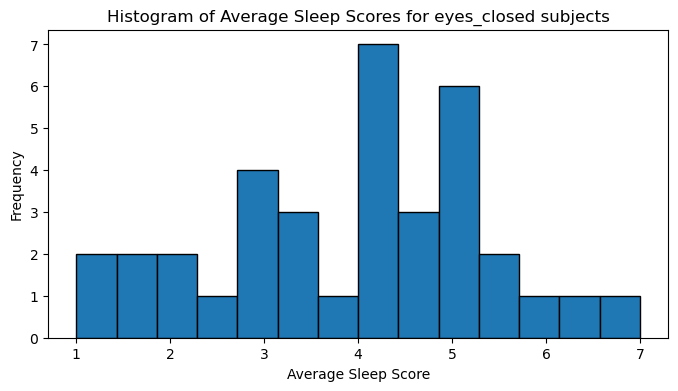

In [101]:
import matplotlib.pyplot as plt

df_ec_sum['avr_sleep_score'].plot.hist(bins=14, edgecolor='black', figsize=(8,4))
plt.xlabel('Average Sleep Score')
plt.title('Histogram of Average Sleep Scores for eyes_closed subjects')
plt.show()

In [112]:
df_ec_sum["avr_sleep_score"].describe()

count    36.000000
mean      3.887536
std       1.453417
min       1.000000
25%       3.000000
50%       4.000000
75%       5.000000
max       7.000000
Name: avr_sleep_score, dtype: float64

### Average Sleep Scores By Subject for Eyes Opened

In [102]:
df_eo_count = df[df["category"].isna()].groupby("subject").agg("count").reset_index()
df_eo_count.head()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category
0,INET016,30,30,30,30,30,30,26,30,0,0
1,INET018,31,31,31,31,31,31,29,31,0,0
2,INET019,31,31,31,31,31,31,26,31,0,0
3,INET027,31,31,31,31,31,31,28,31,0,0
4,INET029,34,34,34,34,34,34,0,34,0,0


In [106]:
len(df_eo_count) == len(df_eo_sum)

True

In [107]:
df_eo_sum["avr_sleep_score"] = df_eo_sum["sleep.score"] / df_eo_count["session"]
df_eo_sum.tail()

,subject,session,run,task,file,path,FD,sleep.score,time,FD-hold,category,avr_sleep_score
85,INET158,76,128,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET158_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7883,15.0,144.521667,0.0,0,0.500000
86,INET159,77,136,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET159_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7417,45.0,135.978333,0.0,0,1.451613
87,INET160,77,128,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET160_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7638,121.0,140.030000,0.0,0,4.033333
88,INET165,68,105,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET165_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,6330,73.0,116.050000,0.0,0,2.703704
89,INET168,78,133,restrestrestrestrestrestrestrestrestrestrestre...,sub-INET168_ses-1_task-rest_desc-framenums_fFD...,/Volumes/illinois-las-psych-gratton/iNetworks/...,7746,47.0,142.010000,0.0,0,1.566667


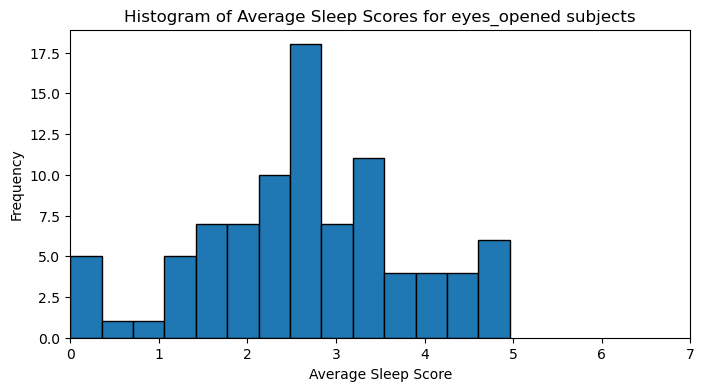

In [116]:
df_eo_sum['avr_sleep_score'].plot.hist(bins=14, edgecolor='black', figsize=(8,4))
plt.xlim(0,7)
plt.xlabel('Average Sleep Score')
plt.title('Histogram of Average Sleep Scores for eyes_opened subjects')
plt.show()

In [113]:
df_eo_sum["avr_sleep_score"].describe()

count    90.000000
mean      2.658390
std       1.199416
min       0.000000
25%       1.956221
50%       2.672619
75%       3.342216
max       4.962963
Name: avr_sleep_score, dtype: float64

In [115]:
diff_arousal_eyes = df_ec_sum["avr_sleep_score"].mean() - df_eo_sum["avr_sleep_score"].mean()
diff_arousal_eyes

np.float64(1.2291460786523953)